# DDPM para ArtBench-10

Este notebook implementa um **Denoising Diffusion Probabilistic Model (DDPM)** simples, adaptado ao projeto ArtBench.

Foi pensado para:
- usar o **starter pack do professor**;
- carregar o **subset de 20%** a partir do `training_20_percent.csv`;
- treinar um modelo de difusão em imagens **RGB 32×32**;
- gerar amostras;
- guardar o modelo treinado.

A base conceptual segue a ideia dos **Denoising Diffusion Probabilistic Models**, em que o modelo aprende a prever o ruído adicionado às imagens ao longo de vários passos de difusão. O repositório que enviaste organiza a implementação precisamente em torno de `training.py`, `generate.py`, `evaluate.py` e módulos separados para dataset, processo de difusão e modelo, e usa como referência o paper original DDPM.

## 1. Imports

In [1]:
from __future__ import annotations

import sys
import csv
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid

## 2. Configuração

In [2]:
SEED = 42
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS = 20

TIMESTEPS = 200
BETA_START = 1e-4
BETA_END = 0.02
LR = 2e-4

SAVE_EVERY = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 3. Ajustar caminhos

In [3]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1
SCRIPTS_DIR    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10
TRAINING CSV   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


## 4. Carregar o dataset com o helper do professor

In [4]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)

print("Train size:", len(train_hf))
print("Número de classes:", len(class_names))
print("Classes:", class_names)

Dataset source: kaggle root='D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10'
Train size: 50000
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


## 5. Transform e dataset PyTorch

In [5]:
transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

## 6. Carregar o subset de 20%

In [6]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)
print("Número de IDs lidos do CSV:", len(train_ids_from_csv))

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Subset size:", len(train_ds))
print("Número de batches:", len(train_loader))

Número de IDs lidos do CSV: 10000
Subset size: 10000
Número de batches: 157


## 7. Ver imagens reais

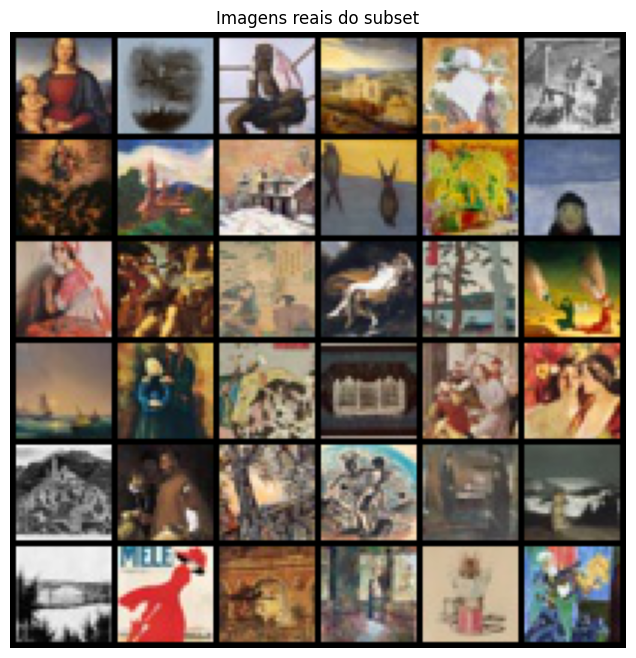

In [7]:
x, y, idx = next(iter(train_loader))
grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset")
plt.show()

## 8. Embeddings de tempo

In [8]:
#igual ao da aula
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb_factor = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_factor)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)
        return emb

## 9. Blocos do modelo

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.act(h)

        time_term = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_term

        h = self.conv2(h)
        h = self.bn2(h)
        h = self.act(h)
        return h


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.block = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        h = self.block(x, t_emb)
        p = self.pool(h)
        return h, p


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.block = ConvBlock(out_ch + skip_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.block(x, t_emb)
        return x

## 10. U-Net simples para DDPM

In [10]:
class SimpleUNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_emb_dim=128):
        super().__init__()

        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.down1 = DownBlock(in_ch, base_ch, time_emb_dim)
        self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)

        self.mid = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)

        self.up1 = UpBlock(base_ch * 4, base_ch * 2, base_ch * 2, time_emb_dim)
        self.up2 = UpBlock(base_ch * 2, base_ch, base_ch, time_emb_dim)

        self.out = nn.Conv2d(base_ch, 3, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_emb(t)

        s1, p1 = self.down1(x, t_emb)
        s2, p2 = self.down2(p1, t_emb)

        m = self.mid(p2, t_emb)

        u1 = self.up1(m, s2, t_emb)
        u2 = self.up2(u1, s1, t_emb)

        return self.out(u2)

## 11. Processo de difusão

In [11]:
betas = torch.linspace(BETA_START, BETA_END, TIMESTEPS).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]], dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

In [12]:
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    return sqrt_alpha_t * x_start + sqrt_one_minus_alpha_t * noise, noise

## 12. Inicializar o modelo

In [13]:
model = SimpleUNet(in_ch=3, base_ch=64, time_emb_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Model params:", sum(p.numel() for p in model.parameters()))

Model params: 1981123


## 13. Função de treino

In [14]:
def train_ddpm(model, train_loader, optimizer, num_epochs, device):
    losses = []

    print("Starting DDPM training...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for x, _, _ in train_loader:
            x = x.to(device)
            bsz = x.size(0)

            t = torch.randint(0, TIMESTEPS, (bsz,), device=device).long()
            noisy_x, noise = q_sample(x, t)
            pred_noise = model(noisy_x, t)

            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.6f}")

    return losses

https://github.com/vikramsandu/Diffusion-Models/tree/main/Denoising%20Diffusion%20Probabilistic%20Models

## 14. Treinar

In [15]:
losses = train_ddpm(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
)

Starting DDPM training...
Epoch [1/20] | Loss: 0.240875
Epoch [2/20] | Loss: 0.126465
Epoch [3/20] | Loss: 0.111743
Epoch [4/20] | Loss: 0.108214
Epoch [5/20] | Loss: 0.104297
Epoch [6/20] | Loss: 0.101929
Epoch [7/20] | Loss: 0.099534
Epoch [8/20] | Loss: 0.097473
Epoch [9/20] | Loss: 0.096286
Epoch [10/20] | Loss: 0.094358
Epoch [11/20] | Loss: 0.095723
Epoch [12/20] | Loss: 0.094283
Epoch [13/20] | Loss: 0.093891
Epoch [14/20] | Loss: 0.091286
Epoch [15/20] | Loss: 0.090302
Epoch [16/20] | Loss: 0.089353
Epoch [17/20] | Loss: 0.090169
Epoch [18/20] | Loss: 0.090642
Epoch [19/20] | Loss: 0.086664
Epoch [20/20] | Loss: 0.088174


## 15. Curva de loss

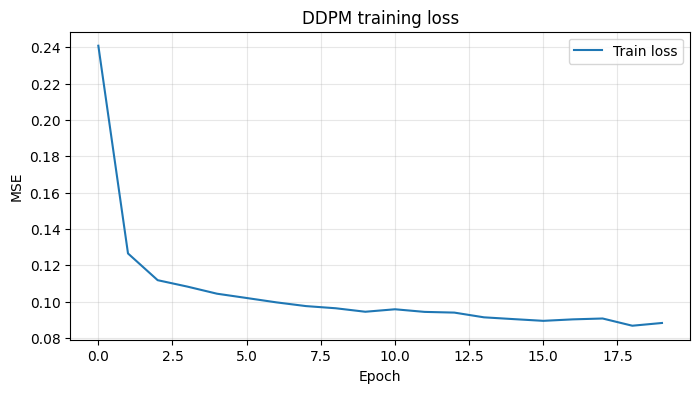

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("DDPM training loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 16. Sampling reverso

In [17]:
@torch.no_grad()
def p_sample(model, x, t):
    betas_t = betas[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_recip_alphas_t = sqrt_recip_alphas[t].view(-1, 1, 1, 1)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    posterior_variance_t = posterior_variance[t].view(-1, 1, 1, 1)

    noise = torch.randn_like(x)
    nonzero_mask = (t != 0).float().view(-1, 1, 1, 1)

    return model_mean + nonzero_mask * torch.sqrt(posterior_variance_t) * noise


@torch.no_grad()
def sample_ddpm(model, n=16):
    model.eval()
    x = torch.randn(n, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

    for i in reversed(range(TIMESTEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t)

    return denorm(x.cpu())

## 17. Gerar imagens

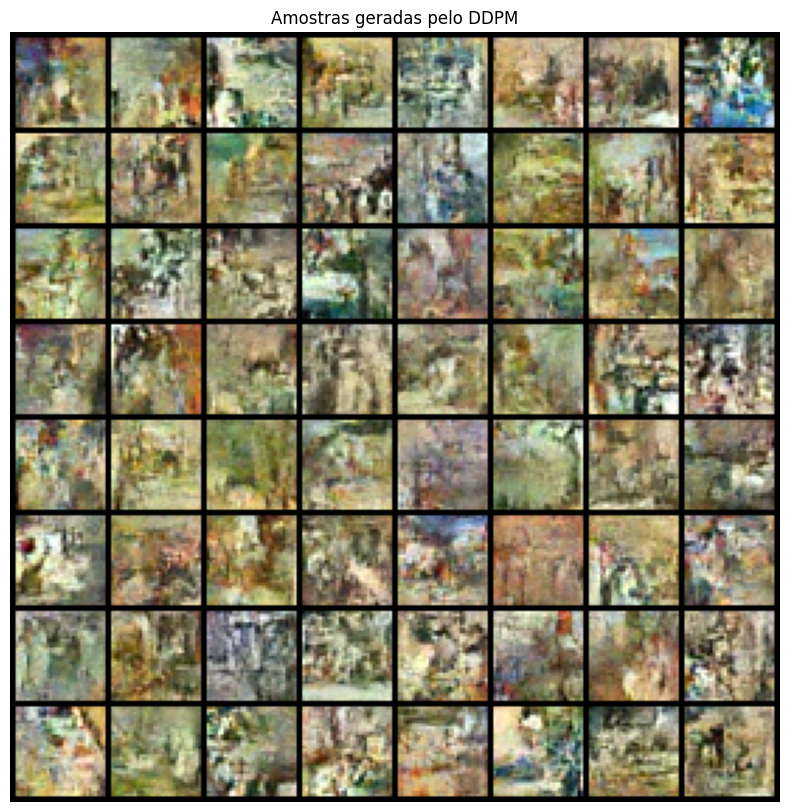

In [18]:
samples = sample_ddpm(model, n=64)

grid = make_grid(samples, nrow=8, padding=2)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Amostras geradas pelo DDPM")
plt.show()

In [19]:
# --- Avaliacao: FID/KID (como nos outros notebooks) ---
# Se faltar dependencia, executar numa celula: %pip install torchmetrics[image]
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

N_EVAL_SAMPLES = 5000
EVAL_BATCH_SIZE = 64

@torch.no_grad()
def collect_real_images(dataloader, n_samples=5000):
    real_batches = []
    total = 0

    for x, _, _ in dataloader:
        x = denorm(x.cpu())
        real_batches.append(x)
        total += x.size(0)
        if total >= n_samples:
            break

    return torch.cat(real_batches, dim=0)[:n_samples]


@torch.no_grad()
def generate_fake_images_ddpm(model, n_samples=5000, batch_size=64):
    fake_batches = []
    total = 0

    while total < n_samples:
        current_batch = min(batch_size, n_samples - total)
        fake = sample_ddpm(model, n=current_batch)  # ja vem em [0,1]
        fake_batches.append(fake)
        total += current_batch

    return torch.cat(fake_batches, dim=0)


def to_uint8(x):
    return (x * 255).clamp(0, 255).to(torch.uint8)


def compute_fid_kid(real_images, fake_images, device, batch_size=64):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(subset_size=100).to(device)

    for start in range(0, len(real_images), batch_size):
        batch = to_uint8(real_images[start:start + batch_size]).to(device)
        fid.update(batch, real=True)
        kid.update(batch, real=True)

    for start in range(0, len(fake_images), batch_size):
        batch = to_uint8(fake_images[start:start + batch_size]).to(device)
        fid.update(batch, real=False)
        kid.update(batch, real=False)

    fid_value = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    return {
        "fid": fid_value,
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


real_images = collect_real_images(train_loader, n_samples=N_EVAL_SAMPLES)
fake_images = generate_fake_images_ddpm(model, n_samples=N_EVAL_SAMPLES, batch_size=EVAL_BATCH_SIZE)

metrics = compute_fid_kid(real_images, fake_images, device=device, batch_size=EVAL_BATCH_SIZE)
print(metrics)

C:\Users\ritam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


{'fid': 184.5948028564453, 'kid_mean': 0.20129609107971191, 'kid_std': 0.0119140250608325}


## 18. Guardar o modelo

In [20]:
OUTPUT_DIR = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), OUTPUT_DIR / "ddpm_subset20.pth")
print("Modelo guardado em:", OUTPUT_DIR.resolve())

Modelo guardado em: D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\checkpoints
